In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
df = pd.read_csv(r"C:\Users\sai guna ranjan\Twitter_Data.csv")


In [3]:
df.head()


,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  str    
 1   category    162973 non-null  float64
dtypes: float64(1), str(1)
memory usage: 2.5 MB


In [5]:
df.isnull().sum()


clean_text    4
category      7
dtype: int64

In [6]:
df.dropna(inplace=True)


In [7]:
df.rename(columns={'clean_text':'text', 'category':'sentiment'}, inplace=True)


In [8]:
df['sentiment'].unique()


array([-1.,  0.,  1.])

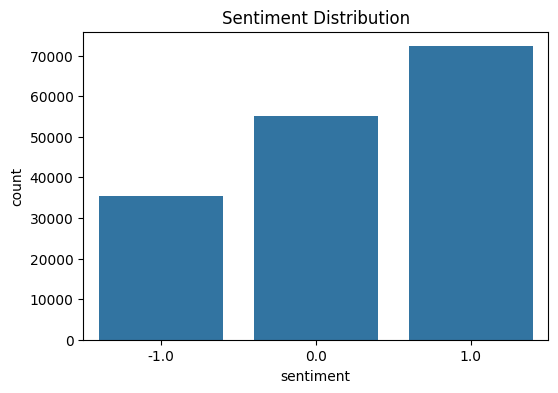

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()


In [10]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    return text


In [11]:
df['text'] = df['text'].apply(clean_text)


In [12]:
X = df['text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [13]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [14]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print("\nClassification Report:\n", classification_report(y_test, nb_pred))


Naive Bayes Accuracy: 0.7049456955267841

Classification Report:
               precision    recall  f1-score   support

        -1.0       0.86      0.43      0.58      7152
         0.0       0.79      0.64      0.70     11067
         1.0       0.64      0.89      0.75     14375

    accuracy                           0.70     32594
   macro avg       0.76      0.65      0.68     32594
weighted avg       0.74      0.70      0.69     32594



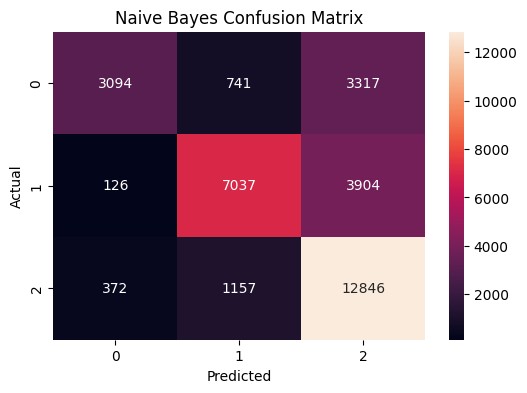

In [15]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, nb_pred), annot=True, fmt='d')
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [16]:
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("\nClassification Report:\n", classification_report(y_test, svm_pred))


SVM Accuracy: 0.8619377799595017

Classification Report:
               precision    recall  f1-score   support

        -1.0       0.85      0.78      0.81      7152
         0.0       0.82      0.96      0.88     11067
         1.0       0.91      0.83      0.87     14375

    accuracy                           0.86     32594
   macro avg       0.86      0.85      0.85     32594
weighted avg       0.87      0.86      0.86     32594



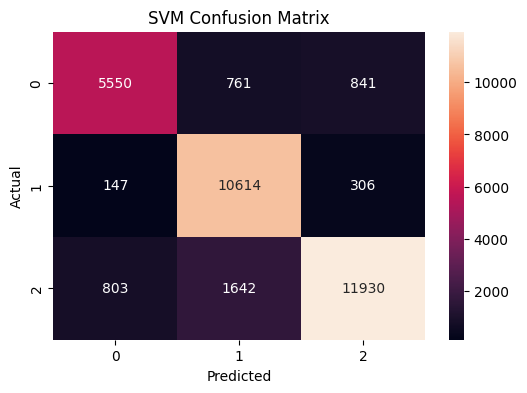

In [17]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt='d')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [18]:
sample = ["Modi government has done excellent work"]

sample_clean = [clean_text(text) for text in sample]
sample_vector = vectorizer.transform(sample_clean)

prediction = svm_model.predict(sample_vector)

sentiment_map = {-1: "Negative", 0: "Neutral", 1: "Positive"}

print("Predicted Sentiment:", sentiment_map[prediction[0]])


Predicted Sentiment: Positive
